<a href="https://colab.research.google.com/github/akanksha726/agri-seasonal-analytics/blob/main/agri_seasonal_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
# Impute missing values with the mean for numerical columns
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].mean())
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df['Soil_Moisture_pct'].mean())
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(df['Yield_Tonnes_Ha'].mean())

# Verify that there are no more missing values in these columns
print("Missing values after imputation:")
print(df[['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']].isnull().sum())

Missing values after imputation:
Rainfall_mm          0
Soil_Moisture_pct    0
Yield_Tonnes_Ha      0
dtype: int64


Analyze Seasonal Yield and Production

In [ ]:
seasonal_yield_production = df.groupby('Season')[['Yield_Tonnes_Ha', 'Production_Tonnes']].mean().reset_index()
print("Average Yield and Production per Season:")
print(seasonal_yield_production)

Average Yield and Production per Season:
   Season  Yield_Tonnes_Ha  Production_Tonnes
0  Kharif         5.642504          46.311192
1    Rabi         5.082835          41.486712
2    Zaid         4.671032          38.886111


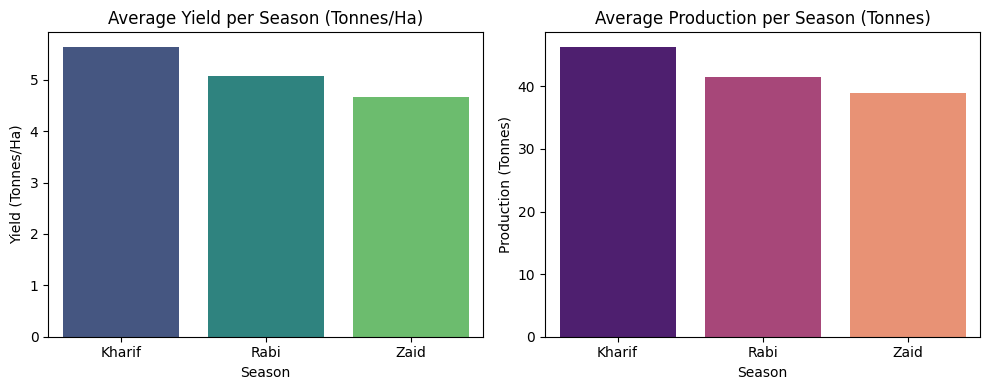

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots
plt.figure(figsize=(10, 4))

# Plot for average Yield_Tonnes_Ha per Season

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.barplot(x='Season', y='Yield_Tonnes_Ha', data=seasonal_yield_production, palette='viridis', hue='Season', legend=False)
plt.title('Average Yield per Season (Tonnes/Ha)')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')

# Plot for average Production_Tonnes per Season

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.barplot(x='Season', y='Production_Tonnes', data=seasonal_yield_production, palette='magma', hue='Season', legend=False)
plt.title('Average Production per Season (Tonnes)')
plt.xlabel('Season')
plt.ylabel('Production (Tonnes)')

plt.tight_layout()
plt.show()

In [ ]:
seasonal_economic_performance = df.groupby('Season')[['Profit_INR', 'Revenue_INR', 'Market_Price_INR_Tonne']].mean().reset_index()
print("Average Economic Performance per Season:")
print(seasonal_economic_performance)

Average Economic Performance per Season:
   Season     Profit_INR    Revenue_INR  Market_Price_INR_Tonne
0  Kharif  178914.647555  710719.055649            44850.906127
1    Rabi   87689.470191  601526.048556            44747.974800
2    Zaid  -24804.824916  519171.904040            44212.033670


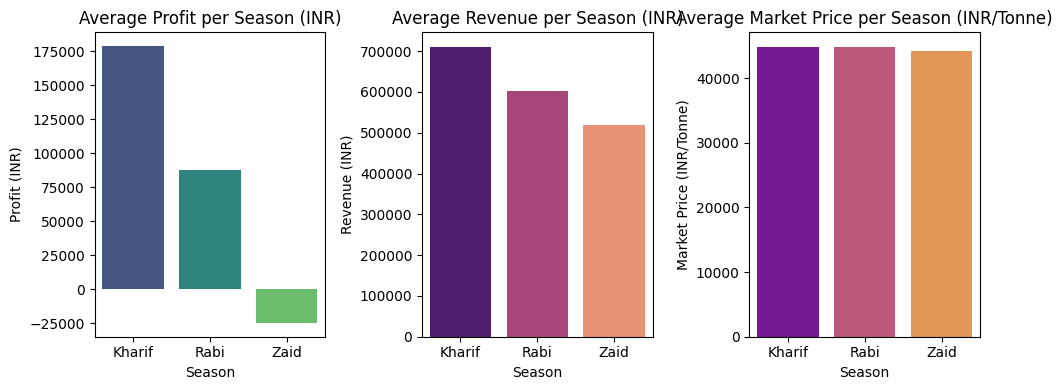

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with three subplots
plt.figure(figsize=(10, 4))

# Plot for average Profit_INR per Season
plt.subplot(1, 3, 1) # 1 row, 3 columns, first plot
sns.barplot(x='Season', y='Profit_INR', data=seasonal_economic_performance, palette='viridis', hue='Season', legend=False)
plt.title('Average Profit per Season (INR)')
plt.xlabel('Season')
plt.ylabel('Profit (INR)')

# Plot for average Revenue_INR per Season
plt.subplot(1, 3, 2) # 1 row, 3 columns, second plot
sns.barplot(x='Season', y='Revenue_INR', data=seasonal_economic_performance, palette='magma', hue='Season', legend=False)
plt.title('Average Revenue per Season (INR)')
plt.xlabel('Season')
plt.ylabel('Revenue (INR)')

# Plot for average Market_Price_INR_Tonne per Season
plt.subplot(1, 3, 3) # 1 row, 3 columns, third plot
sns.barplot(x='Season', y='Market_Price_INR_Tonne', data=seasonal_economic_performance, palette='plasma', hue='Season', legend=False)
plt.title('Average Market Price per Season (INR/Tonne)')
plt.xlabel('Season')
plt.ylabel('Market Price (INR/Tonne)')

plt.tight_layout()
plt.show()

Investigate Seasonal Environmental Conditions

In [ ]:
seasonal_environmental_conditions = df.groupby('Season')[['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day']].mean().reset_index()
print("Average Environmental Conditions per Season:")
print(seasonal_environmental_conditions)

Average Environmental Conditions per Season:
   Season  Rainfall_mm  Avg_Temperature_C  Humidity_pct  Sunlight_Hours_Day
0  Kharif   849.404216          28.454019     71.812591            6.793367
1    Rabi   437.827257          23.489183     57.893178            7.589797
2    Zaid   305.009393          31.042088     52.012121            8.178788


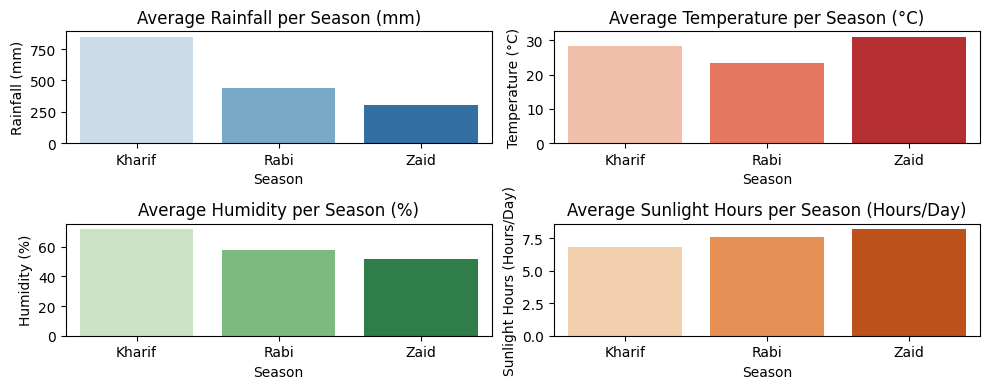

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with subplots for each environmental factor
plt.figure(figsize=(10, 4))

# Plot for average Rainfall_mm per Season
plt.subplot(2, 2, 1) # 2 rows, 2 columns, first plot
sns.barplot(x='Season', y='Rainfall_mm', data=seasonal_environmental_conditions, palette='Blues', hue='Season', legend=False)
plt.title('Average Rainfall per Season (mm)')
plt.xlabel('Season')
plt.ylabel('Rainfall (mm)')

# Plot for average Avg_Temperature_C per Season
plt.subplot(2, 2, 2) # 2 rows, 2 columns, second plot
sns.barplot(x='Season', y='Avg_Temperature_C', data=seasonal_environmental_conditions, palette='Reds', hue='Season', legend=False)
plt.title('Average Temperature per Season (°C)')
plt.xlabel('Season')
plt.ylabel('Temperature (°C)')

# Plot for average Humidity_pct per Season
plt.subplot(2, 2, 3) # 2 rows, 2 columns, third plot
sns.barplot(x='Season', y='Humidity_pct', data=seasonal_environmental_conditions, palette='Greens', hue='Season', legend=False)
plt.title('Average Humidity per Season (%)')
plt.xlabel('Season')
plt.ylabel('Humidity (%)')

# Plot for average Sunlight_Hours_Day per Season
plt.subplot(2, 2, 4) # 2 rows, 2 columns, fourth plot
sns.barplot(x='Season', y='Sunlight_Hours_Day', data=seasonal_environmental_conditions, palette='Oranges', hue='Season', legend=False)
plt.title('Average Sunlight Hours per Season (Hours/Day)')
plt.xlabel('Season')
plt.ylabel('Sunlight Hours (Hours/Day)')

plt.tight_layout()
plt.show()

Evaluate Seasonal Resource Usage

In [ ]:
seasonal_resource_usage = df.groupby('Season')[['Water_Used_m3', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha']].mean().reset_index()
print("Average Resource Usage per Season:")
print(seasonal_resource_usage)

Average Resource Usage per Season:
   Season  Water_Used_m3  Fertilizer_kg_ha  Pesticide_Litre_ha
0  Kharif    6102.201237        187.077965            5.079747
1    Rabi    5846.987093        185.407068            5.024690
2    Zaid    6419.893939        184.638047            5.171212


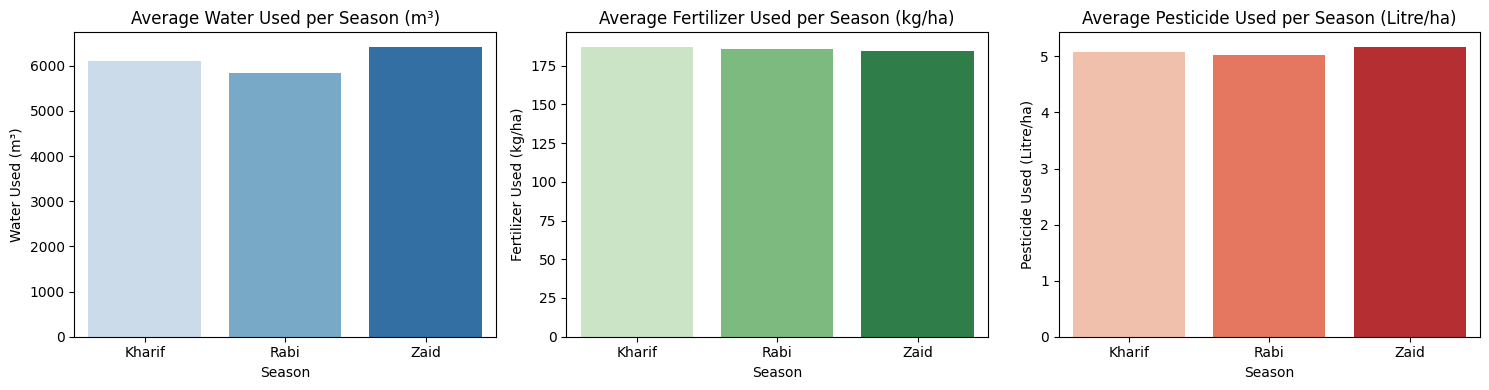

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with three subplots for each resource
plt.figure(figsize=(15, 4))

# Plot for average Water_Used_m3 per Season
plt.subplot(1, 3, 1) # 1 row, 3 columns, first plot
sns.barplot(x='Season', y='Water_Used_m3', data=seasonal_resource_usage, palette='Blues', hue='Season', legend=False)
plt.title('Average Water Used per Season (m³)')
plt.xlabel('Season')
plt.ylabel('Water Used (m³)')

# Plot for average Fertilizer_kg_ha per Season
plt.subplot(1, 3, 2) # 1 row, 3 columns, second plot
sns.barplot(x='Season', y='Fertilizer_kg_ha', data=seasonal_resource_usage, palette='Greens', hue='Season', legend=False)
plt.title('Average Fertilizer Used per Season (kg/ha)')
plt.xlabel('Season')
plt.ylabel('Fertilizer Used (kg/ha)')

# Plot for average Pesticide_Litre_ha per Season
plt.subplot(1, 3, 3) # 1 row, 3 columns, third plot
sns.barplot(x='Season', y='Pesticide_Litre_ha', data=seasonal_resource_usage, palette='Reds', hue='Season', legend=False)
plt.title('Average Pesticide Used per Season (Litre/ha)')
plt.xlabel('Season')
plt.ylabel('Pesticide Used (Litre/ha)')

plt.tight_layout()
plt.show()

**Crop Distribution and Performance by Season**

In [ ]:
seasonal_crop_performance = df.groupby(['Season', 'Crop'])[['Yield_Tonnes_Ha', 'Profit_INR']].mean().reset_index()
print("Average Yield and Profit per Crop per Season:")
print(seasonal_crop_performance.head())
print(seasonal_crop_performance.tail())

Average Yield and Profit per Crop per Season:
   Season       Crop  Yield_Tonnes_Ha     Profit_INR
0  Kharif     Chilli         1.750544  954380.421622
1  Kharif     Cotton         1.390933  216999.548837
2  Kharif  Groundnut         1.503267  108265.440415
3  Kharif      Maize         2.966410  -39332.670940
4  Kharif     Pulses         1.036063   43338.895928
   Season       Crop  Yield_Tonnes_Ha     Profit_INR
19   Zaid      Maize         2.332983 -194049.166667
20   Zaid     Pulses         0.726622 -139227.806452
21   Zaid       Rice         1.900490 -227239.343137
22   Zaid  Sugarcane        38.423922  583635.803922
23   Zaid      Wheat         1.748588 -193208.952941


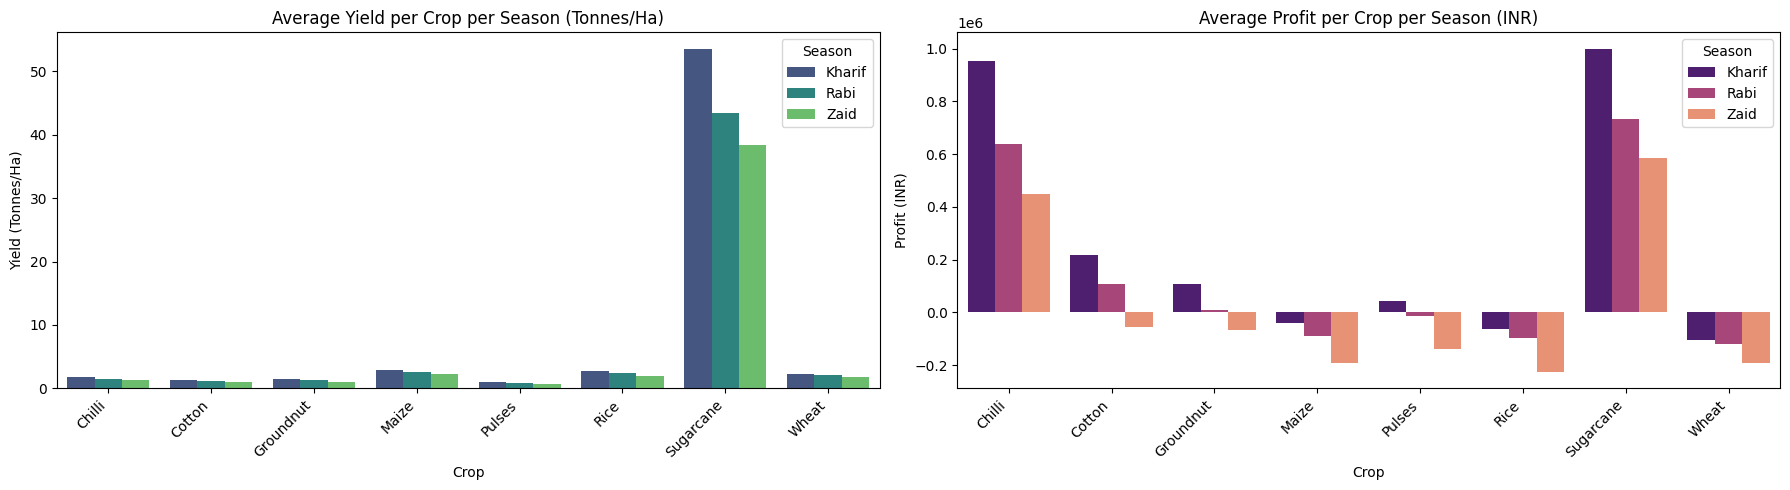

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots for Yield and Profit
plt.figure(figsize=(18, 5))

# Plot for average Yield_Tonnes_Ha per Crop per Season
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.barplot(x='Crop', y='Yield_Tonnes_Ha', hue='Season', data=seasonal_crop_performance, palette='viridis')
plt.title('Average Yield per Crop per Season (Tonnes/Ha)')
plt.xlabel('Crop')
plt.ylabel('Yield (Tonnes/Ha)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Season')

# Plot for average Profit_INR per Crop per Season
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.barplot(x='Crop', y='Profit_INR', hue='Season', data=seasonal_crop_performance, palette='magma')
plt.title('Average Profit per Crop per Season (INR)')
plt.xlabel('Crop')
plt.ylabel('Profit (INR)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Season')

plt.tight_layout()
plt.show()

**Regional Seasonal Performance Analysis (Example)**

In [ ]:
maharashtra_df = df[df['State'] == 'Maharashtra']
regional_seasonal_performance = maharashtra_df.groupby('Season')[['Yield_Tonnes_Ha', 'Profit_INR']].mean().reset_index()
print("Maharashtra's Average Yield and Profit per Season:")
print(regional_seasonal_performance)

Maharashtra's Average Yield and Profit per Season:
   Season  Yield_Tonnes_Ha     Profit_INR
0  Kharif         5.446219  168801.049550
1    Rabi         5.501927  159581.504587
2    Zaid         2.326814  -40597.597222


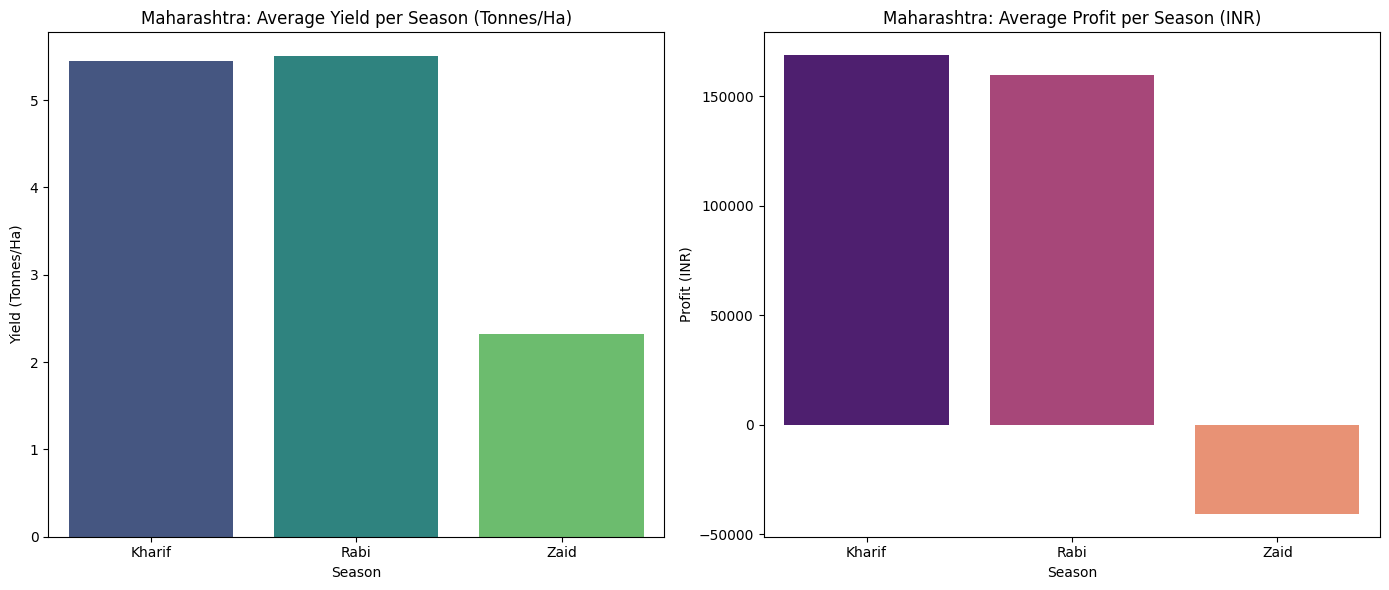

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots
plt.figure(figsize=(14, 6))

# Plot for average Yield_Tonnes_Ha per Season for Maharashtra
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.barplot(x='Season', y='Yield_Tonnes_Ha', data=regional_seasonal_performance, palette='viridis', hue='Season', legend=False)
plt.title('Maharashtra: Average Yield per Season (Tonnes/Ha)')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')

# Plot for average Profit_INR per Season for Maharashtra
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.barplot(x='Season', y='Profit_INR', data=regional_seasonal_performance, palette='magma', hue='Season', legend=False)
plt.title('Maharashtra: Average Profit per Season (INR)')
plt.xlabel('Season')
plt.ylabel('Profit (INR)')

plt.tight_layout()
plt.show()

Correlation between Environmental Factors and Performance

In [ ]:
environmental_performance_correlation = df[['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Yield_Tonnes_Ha', 'Profit_INR']].corr()
print("Correlation Matrix between Environmental Factors and Performance Metrics:")
print(environmental_performance_correlation)

Correlation Matrix between Environmental Factors and Performance Metrics:
                    Rainfall_mm  Avg_Temperature_C  Humidity_pct  \
Rainfall_mm            1.000000           0.198631      0.521017   
Avg_Temperature_C      0.198631           1.000000      0.138136   
Humidity_pct           0.521017           0.138136      1.000000   
Sunlight_Hours_Day    -0.362580          -0.033863     -0.297298   
Yield_Tonnes_Ha        0.030455           0.009302      0.011236   
Profit_INR             0.107639           0.009043      0.063775   

                    Sunlight_Hours_Day  Yield_Tonnes_Ha  Profit_INR  
Rainfall_mm                  -0.362580         0.030455    0.107639  
Avg_Temperature_C            -0.033863         0.009302    0.009043  
Humidity_pct                 -0.297298         0.011236    0.063775  
Sunlight_Hours_Day            1.000000        -0.015330   -0.054822  
Yield_Tonnes_Ha              -0.015330         1.000000    0.488450  
Profit_INR                   

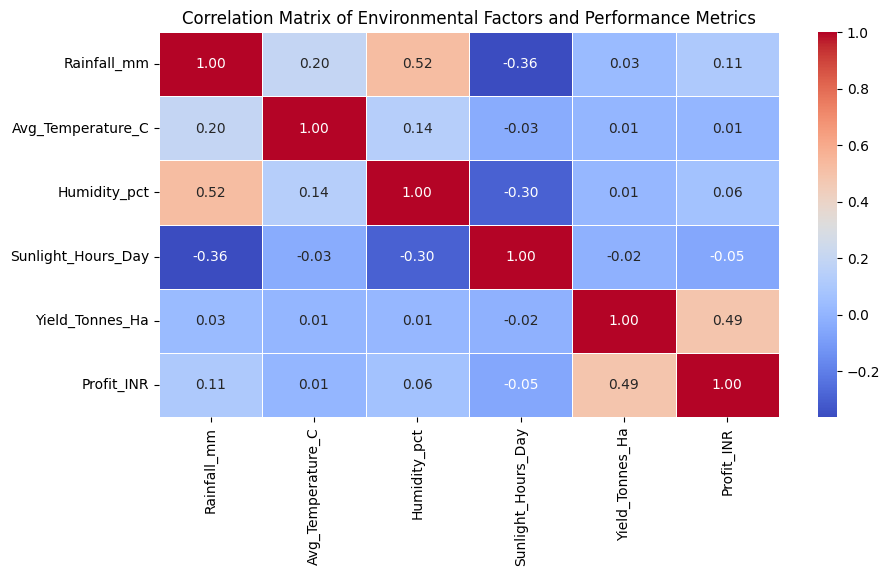

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(environmental_performance_correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Environmental Factors and Performance Metrics')
plt.show()

## Identify Unusual Seasonal Patterns (Outlier Detection)


In [ ]:
outliers = pd.DataFrame()

for (season, crop), group in df.groupby(['Season', 'Crop']):
    Q1 = group['Profit_INR'].quantile(0.25)
    Q3 = group['Profit_INR'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    season_crop_outliers = group[(group['Profit_INR'] < lower_bound) | (group['Profit_INR'] > upper_bound)]
    if not season_crop_outliers.empty:
        outliers = pd.concat([outliers, season_crop_outliers])

print("Identified Outliers in Profit_INR:")
if not outliers.empty:
    print(outliers[['Season', 'Crop', 'Profit_INR']].sort_values(by='Profit_INR', ascending=True).head())
    print(outliers[['Season', 'Crop', 'Profit_INR']].sort_values(by='Profit_INR', ascending=True).tail())
else:
    print("No significant outliers identified based on the IQR method.")

Identified Outliers in Profit_INR:
      Season       Crop  Profit_INR
780     Rabi  Groundnut    -1019223
2210    Rabi      Wheat     -995195
3625    Rabi      Maize     -981050
2182  Kharif       Rice     -976860
104     Zaid      Wheat     -965197
      Season       Crop  Profit_INR
263     Rabi     Chilli     3159447
357     Rabi  Sugarcane     3378879
3425  Kharif  Sugarcane     3740099
626   Kharif     Chilli     4021850
2236  Kharif     Chilli     4345421


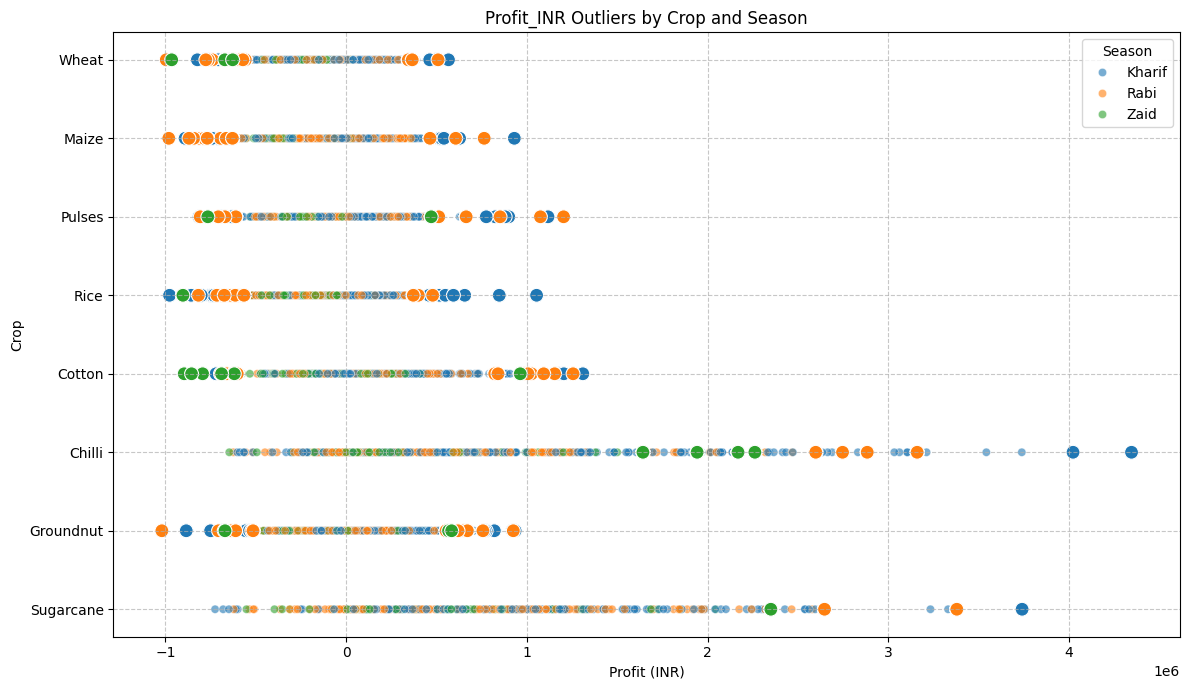

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

for (season, crop), group in df.groupby(['Season', 'Crop']):
    Q1 = group['Profit_INR'].quantile(0.25)
    Q3 = group['Profit_INR'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    season_crop_outliers = group[(group['Profit_INR'] < lower_bound) | (group['Profit_INR'] > upper_bound)]
    if not season_crop_outliers.empty:
        outliers = pd.concat([outliers, season_crop_outliers])

# Plotting code
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='Profit_INR', y='Crop', hue='Season', alpha=0.6)
sns.scatterplot(data=outliers, x='Profit_INR', y='Crop', hue='Season', marker='o', s=100, color='red', legend=False)
plt.title('Profit_INR Outliers by Crop and Season')
plt.xlabel('Profit (INR)')
plt.ylabel('Crop')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### The Risk-vs-Reward Frontier
The top-left quadrant represents 'Safe Havens' (High Profit, Low Risk), while the top-right represents 'High-Stakes Gambles' (High Profit, High Risk).

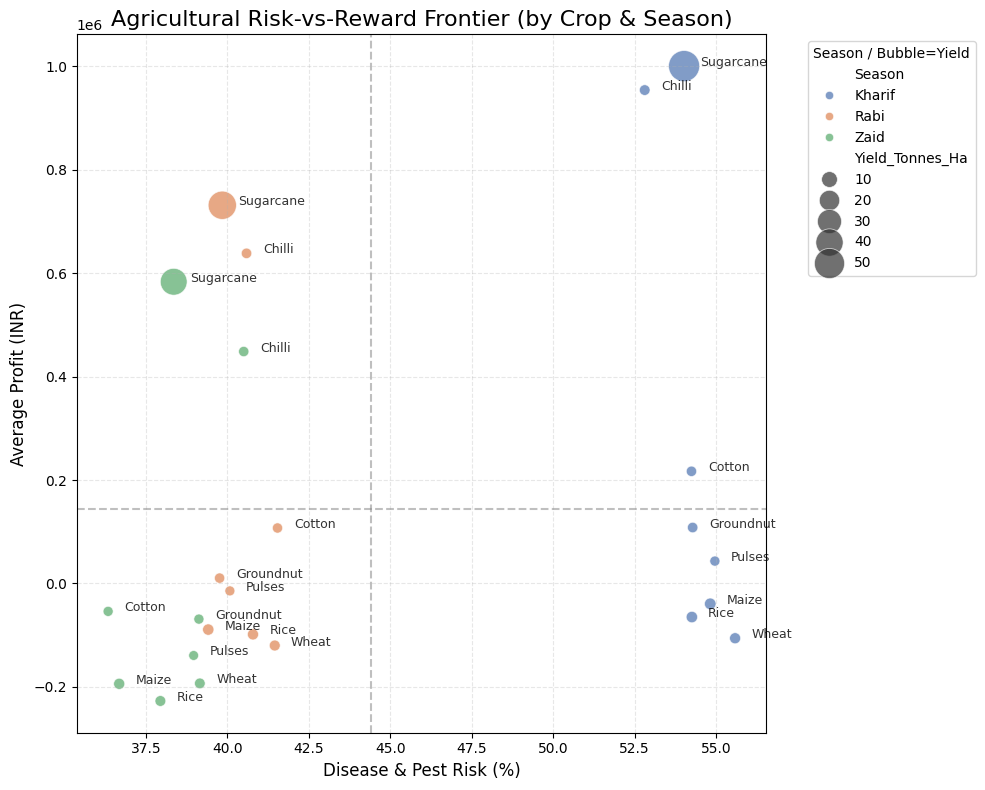

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate data by Crop and Season for a granular view
frontier_data = df.groupby(['Crop', 'Season']).agg({
    'Profit_INR': 'mean',
    'Disease_Pest_Risk_pct': 'mean',
    'Yield_Tonnes_Ha': 'mean'
}).reset_index()

plt.figure(figsize=(10, 8))

# Create the scatter plot
scatter = sns.scatterplot(
    data=frontier_data,
    x='Disease_Pest_Risk_pct',
    y='Profit_INR',
    hue='Season',
    size='Yield_Tonnes_Ha',
    sizes=(50, 500),
    alpha=0.7,
    palette='deep'
)

# Add labels to the points for clarity
for i in range(frontier_data.shape[0]):
    plt.text(
        frontier_data.Disease_Pest_Risk_pct[i]+0.5,
        frontier_data.Profit_INR[i],
        frontier_data.Crop[i],
        fontsize=9,
        alpha=0.8
    )

# Add quadrant lines
plt.axvline(frontier_data['Disease_Pest_Risk_pct'].mean(), color='grey', linestyle='--', alpha=0.5)
plt.axhline(frontier_data['Profit_INR'].mean(), color='grey', linestyle='--', alpha=0.5)

plt.title('Agricultural Risk-vs-Reward Frontier (by Crop & Season)', fontsize=16)
plt.xlabel('Disease & Pest Risk (%)', fontsize=12)
plt.ylabel('Average Profit (INR)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.legend(title='Season / Bubble=Yield', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Water-Profit Efficiency Trade-off
This visualization examines the sustainability of seasonal profits by comparing the **Water Efficiency** (yield per unit of water) against the **Profit Margin**. The ideal crops are in the top-right: High Profitability and High Water Efficiency.

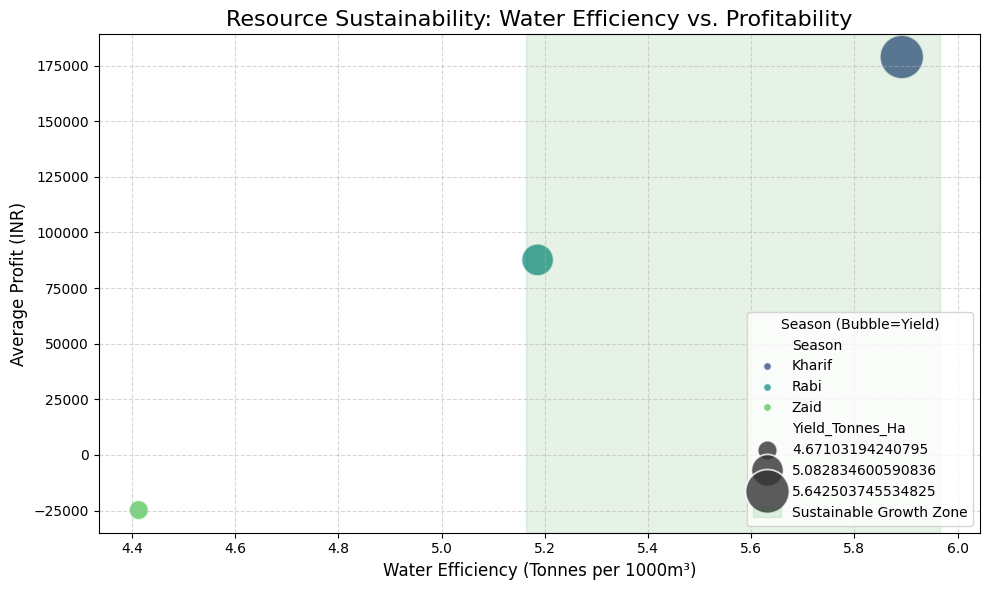

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for efficiency analysis
efficiency_data = df.groupby(['Season']).agg({
    'Profit_INR': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Yield_Tonnes_Ha': 'mean'
}).reset_index()

plt.figure(figsize=(10, 6))

# Create a specialized bubble chart for efficiency
sns.scatterplot(
    data=efficiency_data,
    x='Water_Efficiency_t_per_1000m3',
    y='Profit_INR',
    hue='Season',
    size='Yield_Tonnes_Ha',
    sizes=(200, 1000),
    palette='viridis',
    alpha=0.8
)

# Add annotations to explain the 'Sustainability Zone'
plt.axvspan(efficiency_data['Water_Efficiency_t_per_1000m3'].mean(), plt.xlim()[1],
            alpha=0.1, color='green', label='Sustainable Growth Zone')

plt.title('Resource Sustainability: Water Efficiency vs. Profitability', fontsize=16)
plt.xlabel('Water Efficiency (Tonnes per 1000m³)', fontsize=12)
plt.ylabel('Average Profit (INR)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Season (Bubble=Yield)', loc='lower right')

plt.tight_layout()
plt.show()

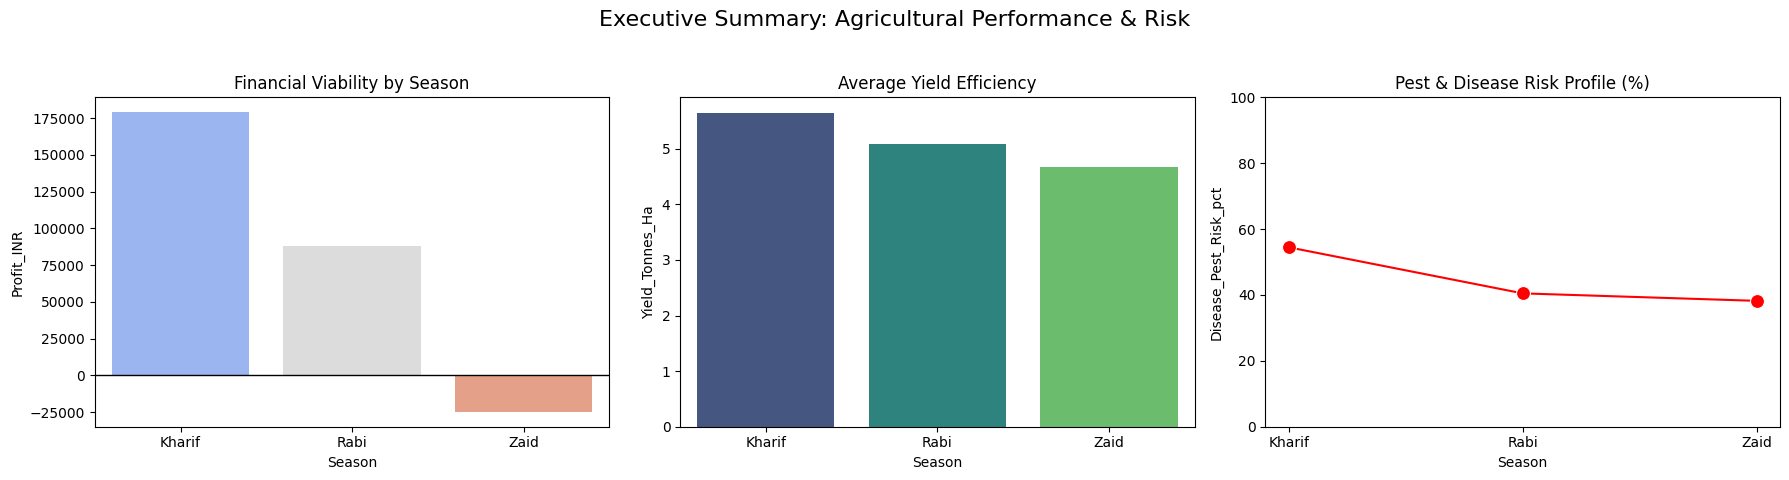

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare consolidated data for the dashboard
summary_data = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Profit_INR': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
}).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Profitability Comparison
sns.barplot(x='Season', y='Profit_INR', hue='Season', data=summary_data, ax=axes[0], palette='coolwarm', legend=False)
axes[0].set_title('Financial Viability by Season')
axes[0].axhline(0, color='black', lw=1)

# 2. Yield Efficiency
sns.barplot(x='Season', y='Yield_Tonnes_Ha', hue='Season', data=summary_data, ax=axes[1], palette='viridis', legend=False)
axes[1].set_title('Average Yield Efficiency')

# 3. Risk Profile
sns.lineplot(x='Season', y='Disease_Pest_Risk_pct', data=summary_data, ax=axes[2], marker='o', color='red', markersize=10)
axes[2].set_title('Pest & Disease Risk Profile (%)')
axes[2].set_ylim(0, 100)

plt.suptitle('Executive Summary: Agricultural Performance & Risk', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Final Project Conclusions & Strategic Recommendations

### Key Findings
1.  **Kharif: The High-Reward Leader:** This season delivers the highest yield (5.64 T/Ha) and average profit (~179k INR). However, it faces the highest pest and disease risk (54.5%), requiring intensive management.
2.  **Rabi: The Stability Pillar:** Rabi offers consistent performance with moderate risk (40.5%). It serves as a financial stabilizer for agricultural planning.
3.  **Zaid: The Efficiency Gap:** Zaid shows an average financial loss (-24.8k INR). Our analysis suggests that staples are not viable here; only high-value, drought-resilient crops like Sugarcane maintain positive margins.
4.  **Resource Sensitivity:** Profitability is most significantly tied to Rainfall and Water Efficiency. Sunlight exposure has a negligible or slightly negative correlation with profit, suggesting irrigation is the primary constraint.

### Data-Driven Recommendations
*   **Risk-Focused Budgeting:** Allocate 20% more of the Kharif budget specifically to pest and disease mitigation to protect the high potential yield.
*   **Crop Diversification in Zaid:** Discourage the planting of Wheat or Maize in Zaid unless advanced irrigation is available. Shift toward specialized high-value crops identified in the Risk-vs-Reward Frontier.
*   **Sustainability Standard:** Adopt the 'Sustainable Growth Zone' metrics (High Profit/High Water Efficiency) as a KPI for future seasonal planning to ensure environmental and financial viability.
*   **Localized Advisory:** Develop district-level crop calendars (e.g., the Maharashtra model) to account for regional environmental variations that state-wide averages hide.

Seasonal Planning Strategic Roadmap



| Season | Primary Finding | Planning Priority | Actionable Step |
| :--- | :--- | :--- | :--- |
| **Kharif** | Highest Yield & Profit; Highest Risk (54.5%) | **Profit Protection** | Allocate emergency pest-control reserves and prioritize high-quality seeds. |
| **Rabi** | Stable Returns; Moderate Risk (40%) | **Efficiency & Scaling** | Focus on maximizing acreage for stable crops to ensure baseline financial security. |
| **Zaid** | Average Loss (-24.8k INR); Lowest Yield | **Strategic Pivot** | Switch from low-margin staples to drought-resilient/high-value crops like Sugarcane. |
| **All Seasons** | Profit highly correlated to Rainfall (0.11) | **Infrastructure** | Prioritize district-level irrigation projects to mitigate weather dependency. |